# Energy Consumption Analysis and Prediction

This project analyzes hourly and daily energy consumption data to identify usage patterns and build a model to predict electricity demand.

## Goals
- Understand how energy usage changes over time
- Identify key factors affecting consumption
- Build a predictive model for energy demand

In [105]:
#Load + Clean

df = pd.read_csv("data/AEP_hourly.csv")

df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime')
df = df.dropna()

df = df.rename(columns={"AEP_MW": "Energy"})

In [ ]:
df['hour'] = df['Datetime'].dt.hour
df['day_of_week'] = df['Datetime'].dt.dayofweek
df['month'] = df['Datetime'].dt.month
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

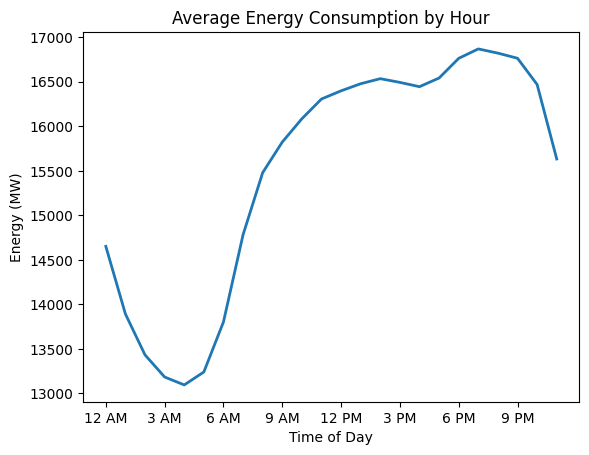

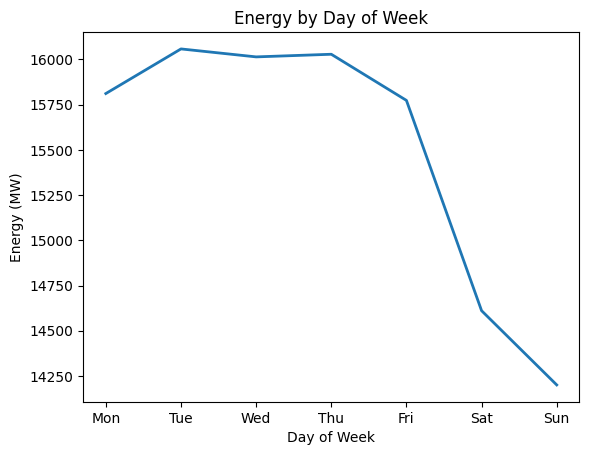

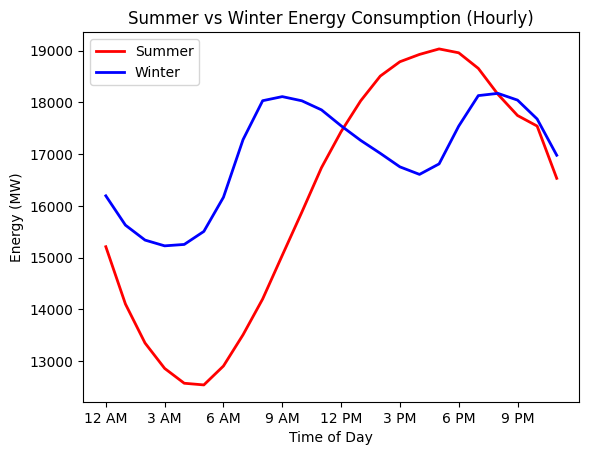

In [107]:
#Graphs

import pandas as pd
import matplotlib.pyplot as plt

hourly = df.groupby('hour')['Energy'].mean()
plt.figure()
plt.plot(hourly.index, hourly.values, linewidth=2)

# Custom increments (every 3 hours)
ticks = list(range(0, 24, 3))
labels = [
    "12 AM","3 AM","6 AM","9 AM",
    "12 PM","3 PM", "6 PM", "9 PM"
]

plt.xticks(ticks, labels)
plt.xlabel("Time of Day")
plt.ylabel("Energy (MW)")
plt.title("Average Energy Consumption by Hour")
plt.show()

#_________________________________________________________________

order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

df['day_name'] = pd.Categorical(
    df['Datetime'].dt.day_name(),
    categories=order,
    ordered=True
)

daily = df.groupby('day_name')['Energy'].mean()

plt.figure()
daily.plot(linewidth=2)

# shorten labels visually
plt.xticks(ticks=range(7), labels=["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])

plt.title("Energy by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Energy (MW)")
plt.show()

#_________________________________________________________________

summer = df[df['month'].isin([6, 7, 8])]
winter = df[df['month'].isin([12, 1, 2])]

summer_hourly = summer.groupby('hour')['Energy'].mean()
winter_hourly = winter.groupby('hour')['Energy'].mean()

plt.figure()

plt.plot(summer_hourly.index, summer_hourly.values, label="Summer", color="red", linewidth=2)
plt.plot(winter_hourly.index, winter_hourly.values, label="Winter", color="blue", linewidth=2)

ticks = list(range(0, 24, 3))
labels = ["12 AM","3 AM","6 AM","9 AM","12 PM","3 PM","6 PM","9 PM"]

plt.xticks(ticks, labels)
plt.xlabel("Time of Day")
plt.ylabel("Energy (MW)")
plt.title("Summer vs Winter Energy Consumption (Hourly)")

plt.legend()
plt.show()


